<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-mldm/blob/master/slides/lab-04-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
subtitle: "Lab 04 - Clustering"
jupyter: python3
execute:
  enabled: false
---

## From lecture to lab

**From lecture:** Clustering and unsupervised validation.

**In this lab:**

- Choose a meaningful representation and similarity measure
- Compare cluster notions across algorithms
- Check whether discovered groups answer a domain question


We will:

- normalize numeric attributes before Euclidean-distance clustering;
- inspect K-means centroids, per-cluster dispersion, sizes, iterations, and SSE;
- evaluate Iris clusters against the known species without using the species during training;
- interpret Food Nutrient partitions for increasing values of $k$;
- compare K-means and DBSCAN on the elongated clusters in Coordinates.

In [335]:
#| echo: false
#| output: false

!pip install -q numpy pandas matplotlib scipy scikit-learn kneed --break-system-packages

from pathlib import Path
from itertools import permutations
from io import BytesIO
from urllib.request import urlopen
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import arff
from kneed import KneeLocator
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 5), "axes.spines.top": False, "axes.spines.right": False})

DATASET_BASE_URL = "https://raw.githubusercontent.com/w4bo/AA2627-unibo-mldm/refs/heads/main/slides/datasets/"


def find_dataset(filename):
    candidates = [
        Path("datasets") / filename,
        Path("slides") / "datasets" / filename,
        Path.cwd() / "datasets" / filename,
        Path.cwd() / "slides" / "datasets" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    return f"{DATASET_BASE_URL}{filename}"


def find_datasets_dir():
    candidates = [Path("datasets"), Path("slides/datasets"), Path.cwd() / "slides" / "datasets"]
    for candidate in candidates:
        if (candidate / "iris.arff").exists():
            return candidate.resolve()
    return DATASET_BASE_URL


DATASETS = find_datasets_dir()
DATASETS


WindowsPath('E:/repos/teaching/AA2627-unibo-mldm/slides/datasets')

In [336]:
#| echo: false
#| output: false

def load_arff_frame(filename):
    # Load an ARFF file locally when available, otherwise from the course dataset URL.
    source = find_dataset(filename)
    if isinstance(source, Path):
        records, _ = arff.loadarff(source)
    else:
        with urlopen(source) as response:
            records, _ = arff.loadarff(BytesIO(response.read()))
    frame = pd.DataFrame(records)
    for column in frame.columns:
        if frame[column].dtype == object:
            frame[column] = frame[column].map(
                lambda value: value.decode("utf-8") if isinstance(value, bytes) else value
            )
    return frame


def cluster_summary(X_scaled, labels, centers, feature_names):
    # Centroid, size, and per-attribute standard-deviation tables.
    center_df = pd.DataFrame(centers, columns=feature_names)
    center_df.index = [f"C{i}" for i in range(len(center_df))]
    std_df = pd.DataFrame(
        [X_scaled[labels == i].std(axis=0, ddof=0) for i in range(len(centers))],
        columns=feature_names,
        index=center_df.index,
    )
    sizes = pd.Series(labels).value_counts().sort_index()
    sizes.index = center_df.index
    sizes.name = "size"
    return center_df, std_df, sizes


def best_cluster_class_mapping(y_true, cluster_labels):
    # Map cluster IDs to classes to maximize correct assignments.
    classes = np.unique(y_true)
    clusters = np.unique(cluster_labels)
    table = pd.crosstab(
        pd.Series(cluster_labels, name="cluster"),
        pd.Series(y_true, name="class"),
    ).reindex(index=clusters, columns=classes, fill_value=0)
    best = None
    for perm in permutations(classes, len(clusters)):
        score = sum(table.loc[cluster, klass] for cluster, klass in zip(clusters, perm))
        if best is None or score > best[0]:
            best = (score, dict(zip(clusters, perm)))
    predicted = np.array([best[1][cluster] for cluster in cluster_labels])
    return table, best[1], predicted, best[0] / len(y_true)



def cluster_entropy_metrics(y_true, cluster_labels):
    # External validation: entropy is low when clusters contain mostly one class.
    table = pd.crosstab(
        pd.Series(cluster_labels, name="cluster"),
        pd.Series(y_true, name="class"),
    )
    probabilities = table.div(table.sum(axis=1), axis=0).replace(0, np.nan)
    entropy_by_cluster = -(probabilities * np.log2(probabilities)).sum(axis=1).fillna(0)
    weights = table.sum(axis=1) / table.values.sum()
    weighted_entropy = float((weights * entropy_by_cluster).sum())
    normalized_entropy = weighted_entropy / np.log2(table.shape[1])
    purity = table.max(axis=1).sum() / table.values.sum()
    metrics = pd.DataFrame({
        "size": table.sum(axis=1),
        "entropy": entropy_by_cluster,
        "weight": weights,
    })
    summary = pd.Series({
        "weighted entropy": weighted_entropy,
        "normalized entropy": normalized_entropy,
        "purity": purity,
    })
    return table, metrics, summary


def hopkins_statistic(X, sample_size=None, random_state=42):
    # Values near 0.5 suggest random spatial structure; values near 1 suggest cluster tendency.
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)
    n_samples, n_features = X.shape
    if sample_size is None:
        sample_size = min(max(n_samples // 10, 20), n_samples - 1)
    sample_size = min(sample_size, n_samples - 1)

    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    random_points = rng.uniform(mins, maxs, size=(sample_size, n_features))
    real_indices = rng.choice(n_samples, size=sample_size, replace=False)
    real_points = X[real_indices]

    random_distances, _ = NearestNeighbors(n_neighbors=1).fit(X).kneighbors(random_points)
    real_distances, _ = NearestNeighbors(n_neighbors=2).fit(X).kneighbors(real_points)
    u = random_distances[:, 0]
    w = real_distances[:, 1]
    return float(u.sum() / (u.sum() + w.sum()))


# The Iris dataset

Iris contains 150 plants, four numeric measurements, and no missing values. 

- `class` is excluded from the distance computation and used only after clustering for external evaluation.


In [337]:
iris = load_arff_frame("iris.arff")
iris.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   class        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


## Preprocessing: normalize before Euclidean distance

Distance-based algorithms are sensitive to scale.


In [338]:
iris_features = ["petallength", "petalwidth"] # "sepallength", "sepalwidth", 
X_iris = iris[iris_features].to_numpy()
y_iris = iris["class"].to_numpy()

iris_scaler = MinMaxScaler()
X_iris_scaled = iris_scaler.fit_transform(X_iris)
feature_index = {name: i for i, name in enumerate(iris_features)}

pd.DataFrame(X_iris_scaled, columns=iris_features).agg(["min", "max"])


,petallength,petalwidth
min,0.0,0.0
max,1.0,1.0


## Iris internal validation: elbow and silhouette

Internal metrics are used to compare clusterings without reference to external labels.

- **SSE / inertia** is the K-means objective, so it must decrease as $k$ grows.
- **Silhouette** compares cohesion with separation; larger values are better, but the score still reflects the geometry preferred by the metric.

For a point $i$:

- $a(i)$ is the mean distance from $i$ to the other points in its own cluster;
- $b(i)$ is the smallest mean distance from $i$ to the points in any other cluster.

The silhouette of point $i$ is:

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}
$$

The silhouette score of a clustering is the mean of $s(i)$ over all points. Values close to $1$ indicate well-separated points, values close to $0$ indicate points near a decision boundary, and negative values suggest possible misassignment.


## Iris internal validation: elbow and silhouette

In [339]:
iris_internal_scores = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=20, max_iter=500, random_state=10)
    labels = model.fit_predict(X_iris_scaled)
    iris_internal_scores.append({ "k": k, "SSE": model.inertia_, "silhouette": silhouette_score(X_iris_scaled, labels), })
iris_internal_scores = pd.DataFrame(iris_internal_scores)
iris_elbow = KneeLocator(iris_internal_scores["k"], iris_internal_scores["SSE"], curve="convex", direction="decreasing",).elbow

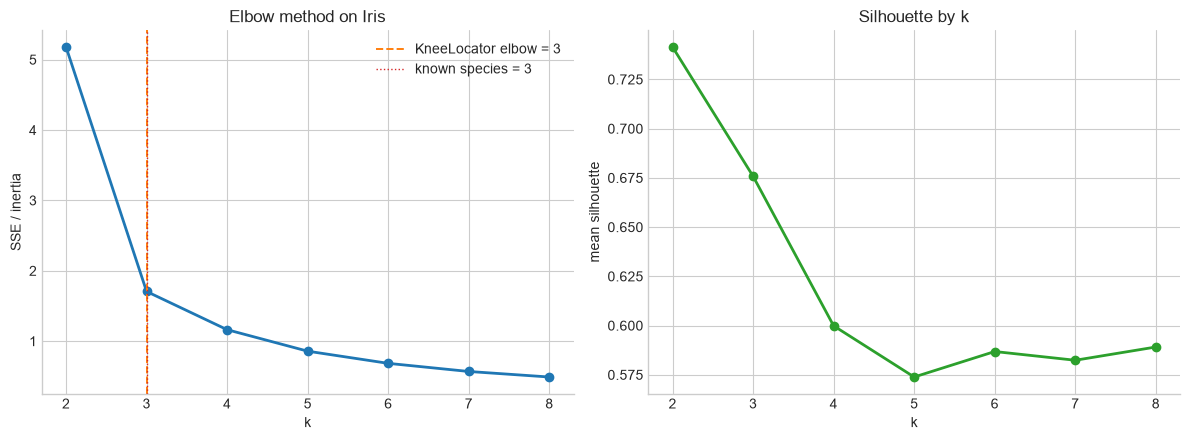

In [340]:
#| echo: false
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(iris_internal_scores["k"], iris_internal_scores["SSE"], marker="o", linewidth=2)
axes[0].set(title="Elbow method on Iris", xlabel="k", ylabel="SSE / inertia")
axes[0].axvline(iris_elbow, color="tab:orange", linestyle="--", linewidth=1.4, label=f"KneeLocator elbow = {iris_elbow}")
axes[0].axvline(3, color="tab:red", linestyle=":", linewidth=1, label="known species = 3")
axes[0].legend()

axes[1].plot(iris_internal_scores["k"], iris_internal_scores["silhouette"], marker="o", linewidth=2, color="tab:green")
axes[1].set(title="Silhouette by k", xlabel="k", ylabel="mean silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()

<details>
<summary>Answer</summary>

`KneeLocator` makes the elbow choice explicit, but the elbow is not always perfectly sharp, which is typical. The large SSE drop from $k=2$ to $k=3$ supports three compact groups, while silhouette asks whether each point is closer to its own cluster than to neighboring clusters. These are internal criteria: they do not know the Iris species.
</details>

## Viswualize the clusterings

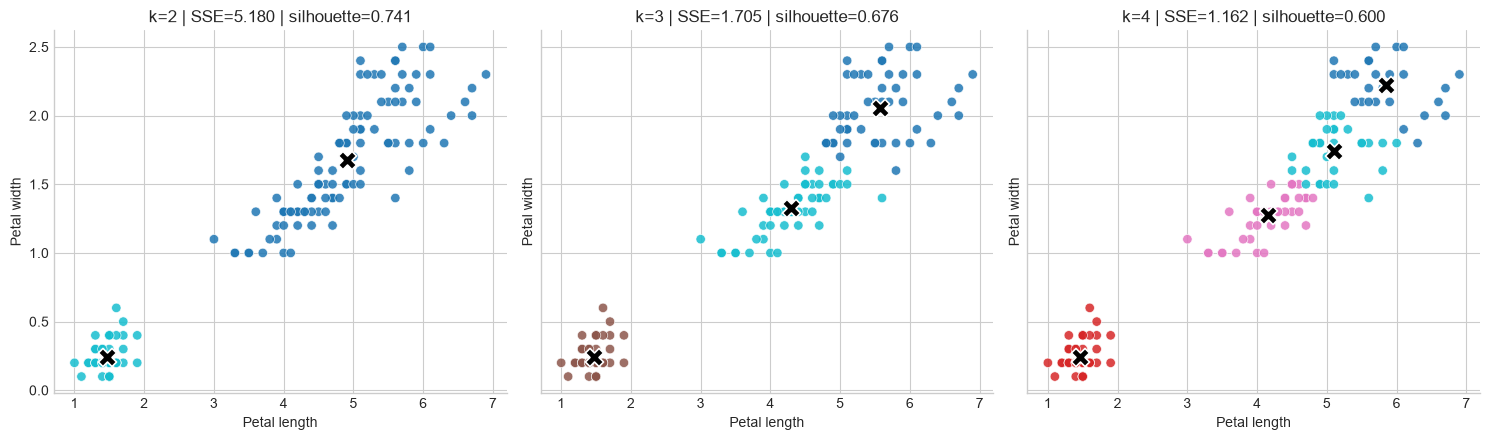

In [341]:
#| echo: false
iris_kmeans_comparison = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, k in zip(axes, [2, 3, 4]):
    model = KMeans(n_clusters=k, n_init=20, max_iter=500, random_state=10)
    labels = model.fit_predict(X_iris_scaled)
    score = silhouette_score(X_iris_scaled, labels)
    iris_kmeans_comparison.append({"k": k, "SSE": model.inertia_, "silhouette": score})

    centers_original = iris_scaler.inverse_transform(model.cluster_centers_)
    centers_original_df = pd.DataFrame(centers_original, columns=iris_features)

    ax.scatter(
        iris["petallength"], iris["petalwidth"],
        c=labels, cmap="tab10", s=46, alpha=0.85,
        edgecolor="white", linewidth=0.5,
    )
    ax.scatter(
        centers_original_df["petallength"], centers_original_df["petalwidth"],
        c="black", marker="X", s=170, linewidth=1.2, edgecolor="white",
    )
    ax.set_title(f"k={k} | SSE={model.inertia_:.3f} | silhouette={score:.3f}")
    ax.set_xlabel("Petal length")
    ax.set_ylabel("Petal width")

iris_kmeans_comparison = pd.DataFrame(iris_kmeans_comparison)
plt.tight_layout()
plt.show()

## K-means when k=3

In [342]:
#| echo: false
iris_kmeans = KMeans(n_clusters=3, n_init=10, max_iter=500, random_state=10)
iris_clusters = iris_kmeans.fit_predict(X_iris_scaled)

iris_centers, iris_stds, iris_sizes = cluster_summary(
    X_iris_scaled, iris_clusters, iris_kmeans.cluster_centers_, iris_features
)

print(f"Iterations to convergence: {iris_kmeans.n_iter_}")
print(f"SSE / inertia: {iris_kmeans.inertia_:.4f}")
print(f"Silhouette: {silhouette_score(X_iris_scaled, iris_clusters):.4f}")


Iterations to convergence: 5
SSE / inertia: 1.7051
Silhouette: 0.6758


In [343]:
iris_centers.round(4)

,petallength,petalwidth
C0,0.7740,0.8151
C1,0.0786,0.0600
C2,0.5587,0.5104


In [344]:
iris_stds.round(4)

,petallength,petalwidth
C0,0.0921,0.0999
C1,0.0291,0.0442
C2,0.0848,0.0766


## Iris cluster-to-class matching

Cluster IDs have no semantic order: we find the one-to-one mapping from clusters to Iris species that maximizes the diagonal of the contingency table.

Given clusters $C_1, \ldots, C_K$ and true classes $L_1, \ldots, L_J$, the **contingency matrix** $M \in \mathbb{N}^{K \times J}$ is defined as:

$$
M_{ij} = |C_i \cap L_j|
$$

Each row describes the true-class composition of one cluster; each column describes how one class is distributed across clusters.


In [345]:
iris_table, iris_mapping, iris_predicted_class, iris_accuracy = best_cluster_class_mapping(y_iris, iris_clusters)
iris_table


class,Iris-setosa,Iris-versicolor,Iris-virginica
cluster,,,
0,0,2,46
1,50,0,0
2,0,48,4


## Iris matched-class confusion matrix


In [346]:
cm = pd.DataFrame(
    confusion_matrix(y_iris, iris_predicted_class, labels=np.unique(y_iris)),
    index=[f"true: {c}" for c in np.unique(y_iris)],
    columns=[f"pred: {c}" for c in np.unique(y_iris)],
)
cm

,pred: Iris-setosa,pred: Iris-versicolor,pred: Iris-virginica
true: Iris-setosa,50,0,0
true: Iris-versicolor,0,48,2
true: Iris-virginica,0,4,46


## Iris external validation: entropy

Because Iris has species labels, we can evaluate the clustering externally after fitting using the contingency matrix. 

- Entropy measures how mixed the true classes are inside each cluster: lower is better, and zero means every cluster contains a single species.

In [347]:
iris_entropy_table, iris_entropy_by_cluster, iris_entropy_summary = cluster_entropy_metrics(y_iris, iris_clusters)
display(iris_entropy_by_cluster.round(4))
print("Summary")
iris_entropy_summary.round(4)

,size,entropy,weight
cluster,,,
0,48,0.2499,0.3200
1,50,-0.0000,0.3333
2,52,0.3912,0.3467


Summary


weighted entropy      0.2156
normalized entropy    0.1360
purity                0.9600
dtype: float64

<details>
<summary>Answer</summary>

Setosa should have very low entropy because it is visually separated. Most of the remaining entropy comes from the overlap between Versicolor and Virginica, so external validation agrees with the earlier scatter plots.
</details>

## Iris clustering tendency: Hopkins statistic

The lecture warns that clustering algorithms can partition even random data. Hopkins statistic checks whether the data look more clustered than uniformly random points in the same feature space.

- $H \approx 0.5$: no strong clustering tendency.
- $H \to 1$: random reference points fall farther from the data than real points do, suggesting cluster structure.

In [ ]:
rng = np.random.default_rng(12)
iris_random_reference = rng.uniform(
    low=X_iris_scaled.min(axis=0),
    high=X_iris_scaled.max(axis=0),
    size=X_iris_scaled.shape,
)
iris_hopkins_examples = pd.DataFrame({
    "dataset": ["Iris", "uniform random reference"],
    "Hopkins": [
        hopkins_statistic(X_iris_scaled, sample_size=50, random_state=10),
        hopkins_statistic(iris_random_reference, sample_size=50, random_state=10),
    ],
})
iris_hopkins_examples.round(3)

,dataset,Hopkins
0,Iris,0.917
1,uniform random reference,0.500


## Iris clustering tendency: Hopkins statistic

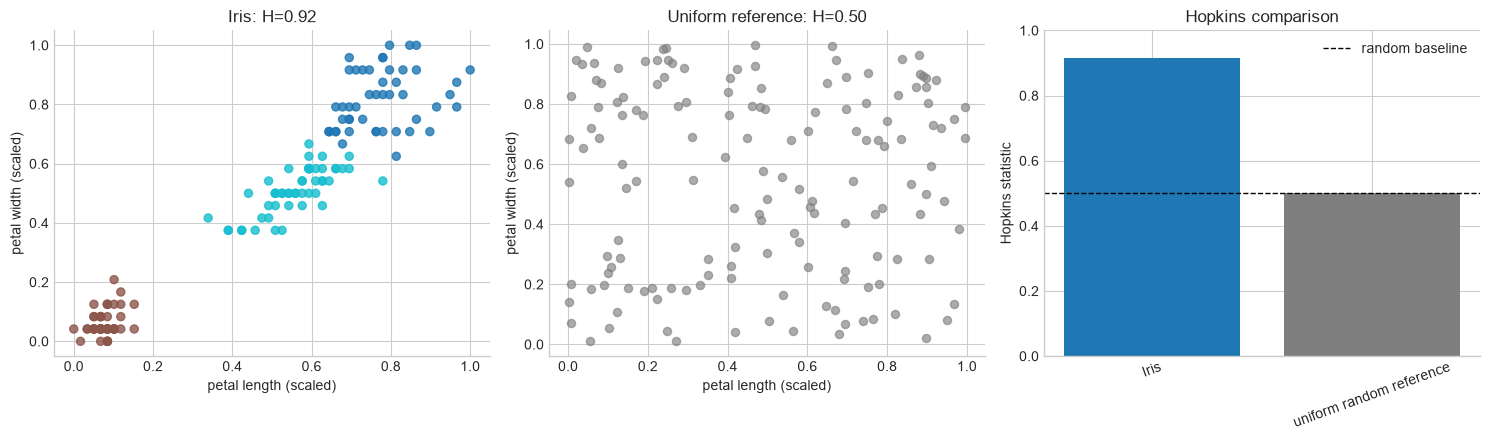

In [ ]:
#| echo: false

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(
    X_iris_scaled[:, feature_index["petallength"]],
    X_iris_scaled[:, feature_index["petalwidth"]],
    c=iris_clusters, cmap="tab10", s=34, alpha=.8,
)
axes[0].set(title=f"Iris: H={iris_hopkins_examples.loc[0, 'Hopkins']:.2f}", xlabel="petal length (scaled)", ylabel="petal width (scaled)")

axes[1].scatter(
    iris_random_reference[:, feature_index["petallength"]],
    iris_random_reference[:, feature_index["petalwidth"]],
    c="gray", s=34, alpha=.65,
)
axes[1].set(title=f"Uniform reference: H={iris_hopkins_examples.loc[1, 'Hopkins']:.2f}", xlabel="petal length (scaled)", ylabel="petal width (scaled)")

axes[2].bar(iris_hopkins_examples["dataset"], iris_hopkins_examples["Hopkins"], color=["tab:blue", "tab:gray"])
axes[2].axhline(.5, color="black", linestyle="--", linewidth=1, label="random baseline")
axes[2].set(title="Hopkins comparison", ylabel="Hopkins statistic", ylim=(0, 1))
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend()

plt.tight_layout()
plt.show()

<details>
<summary>Answer</summary>

Iris should score above the random reference because the petal measurements contain visible groups. Hopkins does not choose the number of clusters; it answers the earlier question of whether applying a clustering algorithm is reasonable at all.
</details>

## We repeat K-means using all features.


In [350]:
#| echo: false
all_features = ["petallength", "petalwidth", "sepallength", "sepalwidth"]
X_petal = MinMaxScaler().fit_transform(iris[all_features])
petal_model = KMeans(n_clusters=3, n_init=10, random_state=10)
petal_clusters = petal_model.fit_predict(X_petal)
petal_table, petal_mapping, petal_predicted, petal_accuracy = best_cluster_class_mapping(y_iris, petal_clusters)
comparison = pd.DataFrame({"features": ["petal only", "all four"], "SSE": [iris_kmeans.inertia_, petal_model.inertia_], "class-match accuracy": [iris_accuracy, petal_accuracy],})
comparison_table = comparison.copy()
comparison_table["SSE"] = comparison_table["SSE"].map(lambda value: f"{value:.4f}")
comparison_table["class-match accuracy"] = comparison_table["class-match accuracy"].map(lambda value: f"{value:.1%}")
comparison_table


,features,SSE,class-match accuracy
0,petal only,1.7051,96.0%
1,all four,6.9981,88.7%


<details>
<summary>Answer</summary>

- Petal measurements preserve the strong Setosa separation and usually improve the external class match.
- Do not compare the two SSE values directly: they live in spaces with different dimensionality.
</details>

## Visual analysis across pairs of attributes

- Setosa should appear well separated.
- Versicolor and virginica overlap most strongly on sepal length and sepal width, while the petal measurements provide clearer separation.


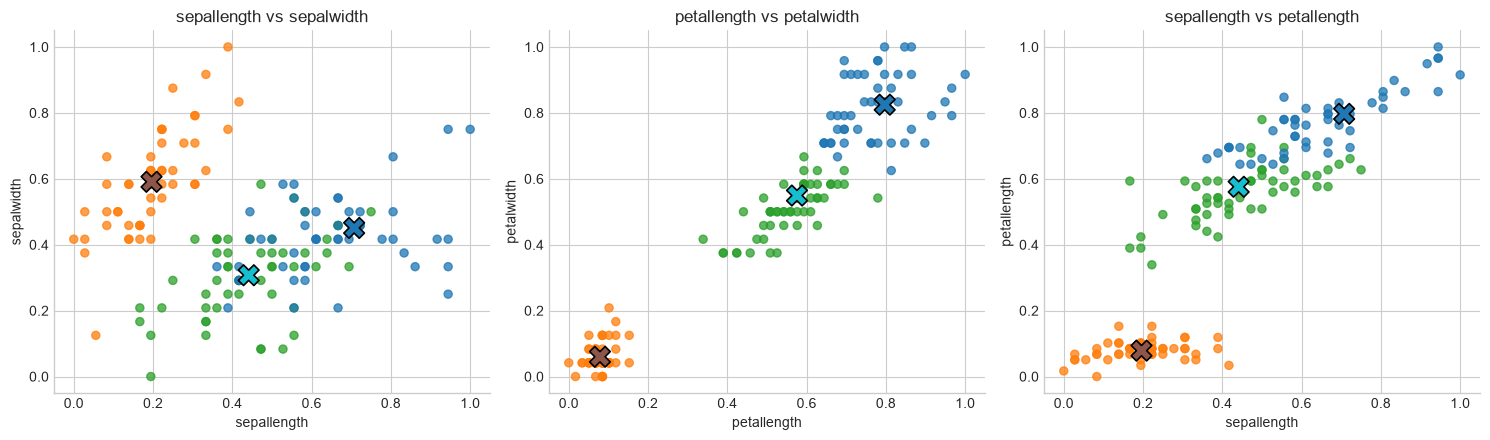

In [351]:
#| echo: false

candidate_pairs = [
    ("sepallength", "sepalwidth"),
    ("petallength", "petalwidth"),
    ("sepallength", "petallength"),
]
pairs = [(x, y) for x, y in candidate_pairs if x in all_features and y in all_features]
feature_index = {name: i for i, name in enumerate(all_features)}
colors = plt.cm.tab10(iris_clusters)

X_iris = iris[all_features].to_numpy()
iris_scaler = MinMaxScaler()
X_iris_scaled = iris_scaler.fit_transform(X_iris)

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5), squeeze=False)
for ax, (x_name, y_name) in zip(axes.flat, pairs):
    x_idx, y_idx = feature_index[x_name], feature_index[y_name]
    ax.scatter(X_iris_scaled[:, x_idx], X_iris_scaled[:, y_idx], c=colors, s=34, alpha=.75)
    ax.scatter(
        petal_model.cluster_centers_[:, x_idx], petal_model.cluster_centers_[:, y_idx],
        marker="X", s=220, c=range(3), cmap="tab10", edgecolor="black", linewidth=1.2,
    )
    ax.set(xlabel=x_name, ylabel=y_name, title=f"{x_name} vs {y_name}")
plt.tight_layout()
plt.show()


# The Food Nutrient dataset

## The Food Nutrient dataset

The file contains nutritional values per 100 g.

- Following the handout, we normalize the five numeric attributes and fit K-means for $k=2,3,4,5,6$.
- The cluster numbers below are **canonicalized** by sorting centroids from high to low energy.
    - This makes tables easier to compare across runs.


In [352]:
food = load_arff_frame("FoodNutrients.arff")
food.head()

,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
0,340.0,20.0,28.0,9.0,2.6
1,245.0,21.0,17.0,9.0,2.7
2,420.0,15.0,39.0,7.0,2.0
3,375.0,19.0,32.0,9.0,2.6
4,180.0,22.0,10.0,17.0,3.7


In [374]:
food_features = list(food.columns)
food_scaler = MinMaxScaler()
X_food = food_scaler.fit_transform(food[food_features])

## Food internal validation: elbow and silhouette

As with Iris, we first compare candidate values of $k$ using internal criteria.

- **SSE / inertia** decreases as $k$ grows, so the elbow is more informative than the absolute minimum.
- **Silhouette** summarizes compactness and separation, but it should be interpreted together with cluster sizes and domain meaning.

In [383]:
#| echo: false
#| output: false

def fit_food_kmeans(k, random_state=10):
    model = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=random_state)
    raw_labels = model.fit_predict(X_food)

    # Stable, readable labels: highest normalized EnergyCal centroid is C0.
    order = np.argsort(model.cluster_centers_[:, 0])[::-1]
    old_to_new = {old: new for new, old in enumerate(order)}
    labels = np.array([old_to_new[label] for label in raw_labels])
    centers_scaled = model.cluster_centers_[order]
    centers_original = food_scaler.inverse_transform(centers_scaled)

    centers, stds, sizes = cluster_summary(X_food, labels, centers_scaled, food_features)
    centers_original = pd.DataFrame(centers_original, columns=food_features, index=centers.index)
    return model, labels, centers, centers_original, stds, sizes


food_results = {}
for k in range(2, 10):
    food_results[k] = fit_food_kmeans(k)

food_internal_scores = pd.DataFrame({
    "k": range(2, 10),
    "SSE": [food_results[k][0].inertia_ for k in range(2, 10)],
    "silhouette": [silhouette_score(X_food, food_results[k][1]) for k in range(2, 10)],
    "smallest cluster": [food_results[k][5].min() for k in range(2, 10)],
})
food_elbow = KneeLocator(
    food_internal_scores["k"],
    food_internal_scores["SSE"],
    curve="convex",
    direction="decreasing",
).elbow


In [388]:
print(f"KneeLocator elbow: k={food_elbow}")
food_internal_scores.round(3)

KneeLocator elbow: k=5


,k,SSE,silhouette,smallest cluster
0,2,5.069,0.379,9
1,3,3.367,0.433,3
2,4,2.559,0.417,2
3,5,1.776,0.395,1
4,6,1.400,0.360,1
5,7,1.014,0.379,1
6,8,0.806,0.401,1
7,9,0.677,0.410,1


## Food internal validation: elbow and silhouette

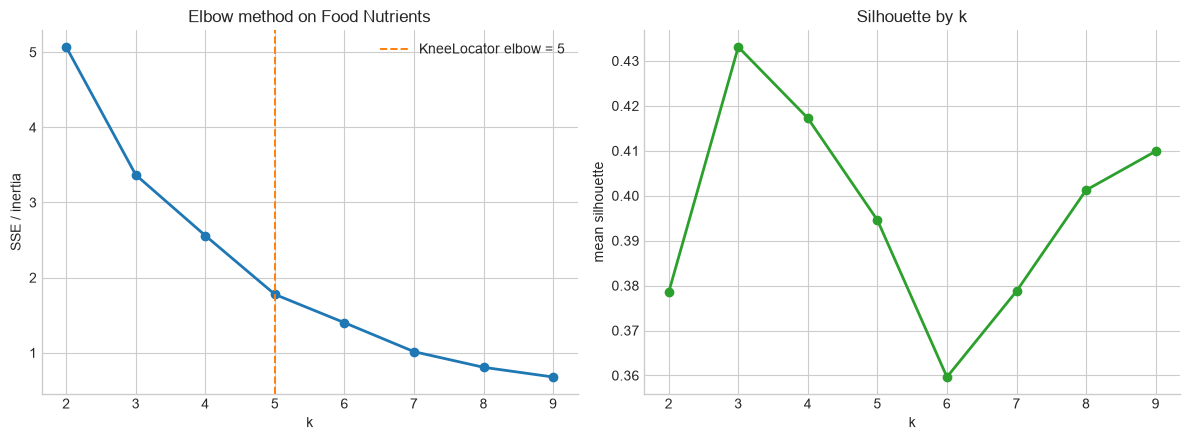

In [386]:
#| echo: false
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(food_internal_scores["k"], food_internal_scores["SSE"], marker="o", linewidth=2)
axes[0].set(title="Elbow method on Food Nutrients", xlabel="k", ylabel="SSE / inertia")
if food_elbow is not None:
    axes[0].axvline(food_elbow, color="tab:orange", linestyle="--", linewidth=1.4, label=f"KneeLocator elbow = {food_elbow}")
    axes[0].legend()

axes[1].plot(food_internal_scores["k"], food_internal_scores["silhouette"], marker="o", linewidth=2, color="tab:green")
axes[1].set(title="Silhouette by k", xlabel="k", ylabel="mean silhouette")

plt.tight_layout()
plt.show()

## Food cluster average profiles

For each candidate clustering, the table reports cluster size and original-scale average nutrient values.

In [387]:
#| echo: false
#| output: false
for k in range(2, 7):
    model, labels, centers, centers_original, stds, sizes = food_results[k]
    table = centers_original.round(1).copy()
    table.insert(0, "size", sizes)
    print(f"k={k} | SSE={model.inertia_:.3f} | silhouette={silhouette_score(X_food, labels):.3f}")
    display(table)

k=2 | SSE=5.069 | silhouette=0.379


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,9,331.1,19.0,27.6,8.8,2.5
C1,18,145.6,19.0,6.4,61.6,2.3


k=3 | SSE=3.367 | silhouette=0.433


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,9,331.1,19.0,27.6,8.8,2.5
C1,15,156.3,19.9,7.3,62.5,1.7
C2,3,91.7,14.7,2.3,56.7,5.8


k=4 | SSE=2.559 | silhouette=0.417


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,8,341.9,18.7,28.9,8.7,2.4
C1,14,163.9,20.7,7.7,19.9,2.0
C2,3,151.7,18.3,7.7,227.7,1.7
C3,2,57.5,9.0,1.0,78.0,5.7


k=5 | SSE=1.776 | silhouette=0.395


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,8,341.9,18.7,28.9,8.7,2.4
C1,1,180.0,22.0,9.0,367.0,2.5
C2,8,178.1,22.9,8.8,21.6,2.8
C3,8,143.1,17.5,6.5,52.6,1.0
C4,2,57.5,9.0,1.0,78.0,5.7


k=6 | SSE=1.400 | silhouette=0.360


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,7,352.9,18.6,30.1,8.7,2.4
C1,7,202.9,22.0,12.0,10.0,2.4
C2,1,180.0,22.0,9.0,367.0,2.5
C3,1,160.0,26.0,5.0,14.0,5.9
C4,9,139.4,18.1,5.9,57.7,1.2
C5,2,57.5,9.0,1.0,78.0,5.7


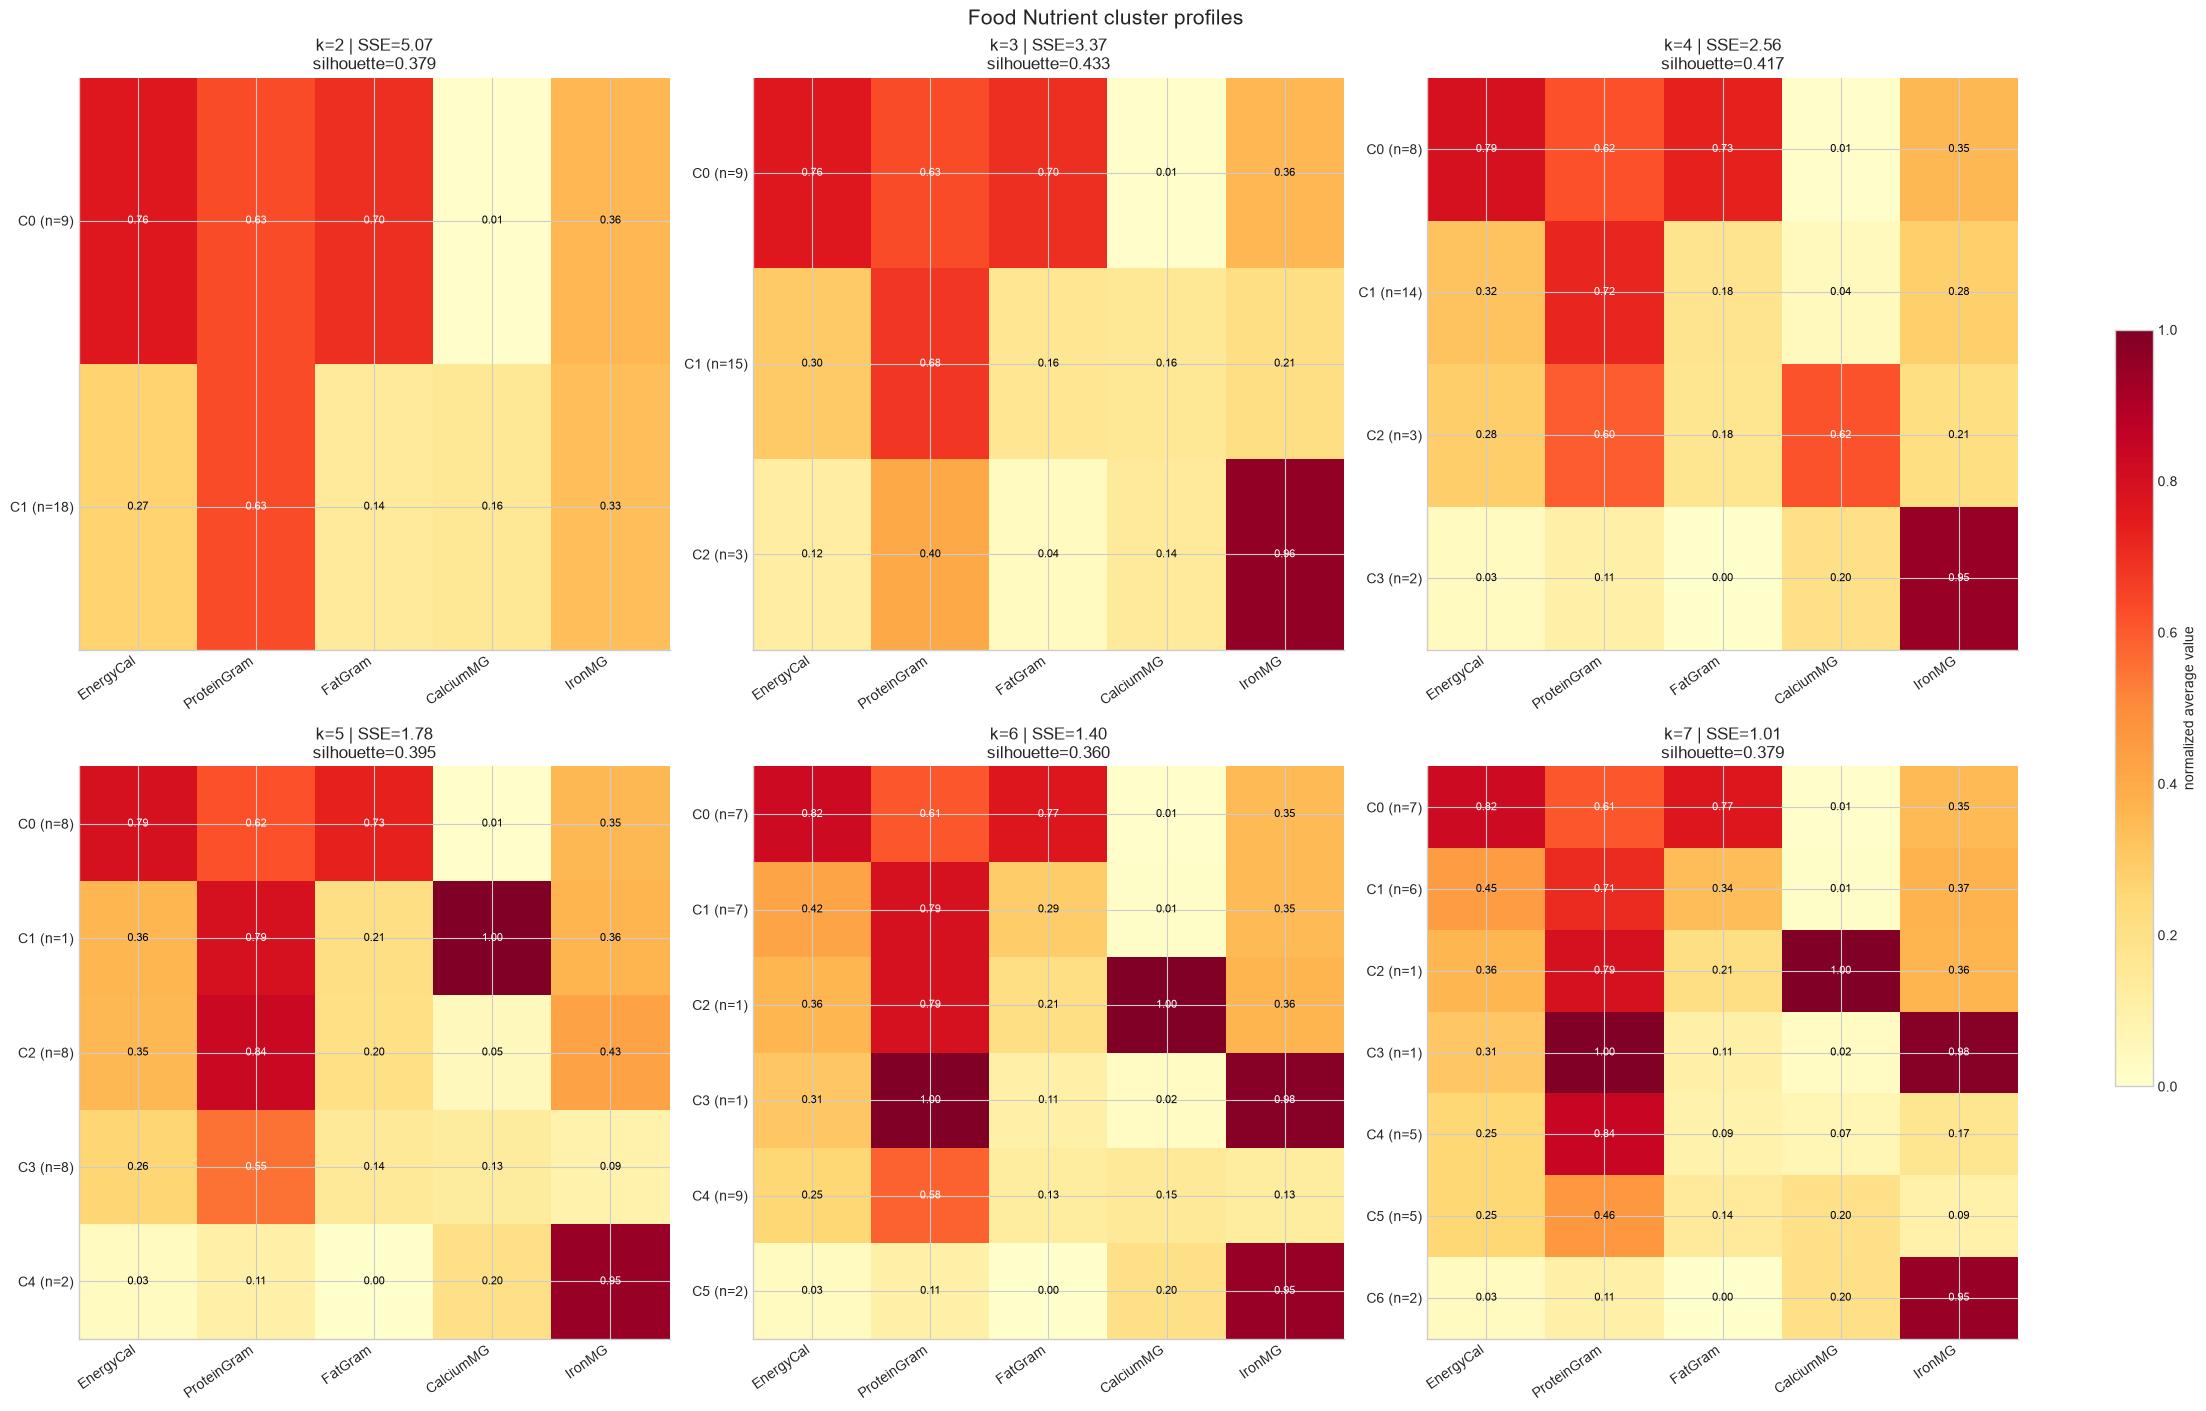

In [391]:
#| echo: false
fig, axes = plt.subplots(2, 3, figsize=(22, 14), constrained_layout=True)
for ax, k in zip(axes.flat, range(2, 8)):
    model, labels, centers, centers_original, stds, sizes = food_results[k]
    image = ax.imshow(centers, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(food_features)), food_features, rotation=35, ha="right")
    ax.set_yticks(range(k), [f"C{i} (n={sizes.iloc[i]})" for i in range(k)])
    ax.set_title(
        f"k={k} | SSE={model.inertia_:.2f}\n"
        f"silhouette={silhouette_score(X_food, labels):.3f}"
    )
    for i in range(k):
        for j in range(len(food_features)):
            value = centers.iloc[i, j]
            ax.text(
                j, i, f"{value:.2f}",
                ha="center", va="center",
                color="white" if value > .55 else "black",
                fontsize=8,
            )
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=.6, label="normalized average value")
fig.suptitle("Food Nutrient cluster profiles", fontsize=15)
plt.show()

<details>
<summary>Answer</summary>

Across increasing $k$, the stable, interpretable profiles are:

- high-energy, high-fat foods;
- high-protein foods with lower fat and energy;
- light but calcium-rich foods;
- a singleton extreme-calcium food when the partition isolates one observation;
- foods with middle-range energy, protein, and fat;
- a light/low-fat but protein-, calcium-, or iron-rich group at the finer partition.

</br>

Iron is often weakly characterized because most values are similar and a few high-iron foods dominate its range.

- Small clusters should be treated cautiously: lower SSE alone does not guarantee a useful segmentation.
</details>


## Verify against the classified file

`FoodNutrientsClassified.arff` contains descriptive fields (`SuperType`, preparation, `Type`, and `Name`) followed by the same numeric nutrients. They are used only to interpret the already fitted $k=6$ clusters.


In [360]:
food_classified = load_arff_frame("FoodNutrientsClassified.arff")
food_classified.head(10)

,SuperType,Preparated,Type,Name,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
0,MEAT,COOKED,BEEF,BEEF_BRAISED,340.0,20.0,28.0,9.0,2.6
1,MEAT,COOKED,BEEF,HAMBURGER,245.0,21.0,17.0,9.0,2.7
2,MEAT,COOKED,BEEF,BEEF_ROAST,420.0,15.0,39.0,7.0,2.0
3,MEAT,COOKED,BEEF,BEEF_STEAK,375.0,19.0,32.0,9.0,2.6
4,MEAT,CANNED,BEEF,BEEF_CANNED,180.0,22.0,10.0,17.0,3.7
5,MEAT,BROILED,CHICKEN,CHICKEN_BROILED,115.0,20.0,3.0,8.0,1.4
6,MEAT,CANNED,CHICKEN,CHICKEN_CANNED,170.0,25.0,7.0,12.0,1.5
7,MEAT,BROILED,BEEF,BEEF_HEART,160.0,26.0,5.0,14.0,5.9
8,MEAT,COOKED,LAMB,LAMB_LEG_ROAST,265.0,20.0,20.0,9.0,2.6
9,MEAT,COOKED,LAMB,LAMB_SHOULDER_ROAST,300.0,18.0,25.0,9.0,2.3


## Food by type


In [361]:
labels6 = food_results[6][1]
food_labeled = food_classified[["Name", "SuperType", "Type"]].copy()
food_labeled.insert(0, "cluster", [f"C{i}" for i in labels6])
food_labeled.head(10)

,cluster,Name,SuperType,Type
0,C0,BEEF_BRAISED,MEAT,BEEF
1,C1,HAMBURGER,MEAT,BEEF
2,C0,BEEF_ROAST,MEAT,BEEF
3,C0,BEEF_STEAK,MEAT,BEEF
4,C1,BEEF_CANNED,MEAT,BEEF
5,C4,CHICKEN_BROILED,MEAT,CHICKEN
6,C1,CHICKEN_CANNED,MEAT,CHICKEN
7,C3,BEEF_HEART,MEAT,BEEF
8,C1,LAMB_LEG_ROAST,MEAT,LAMB
9,C0,LAMB_SHOULDER_ROAST,MEAT,LAMB


## Food clusters by super type

In [362]:
pd.crosstab(food_labeled["cluster"], food_labeled["SuperType"], margins=True)


SuperType,FISH,MEAT,All
cluster,,,
C0,0,7,7
C1,1,6,7
C2,1,0,1
C3,0,1,1
C4,8,1,9
C5,2,0,2
All,12,15,27


## Food clusters by type


In [363]:
pd.crosstab(food_labeled["cluster"], food_labeled["Type"], margins=True)


Type,BEEF,CHICKEN,CLAMS,FISH,LAMB,PORK,SHELLFISH,All
cluster,,,,,,,,
C0,3,0,0,0,1,3,0,7
C1,4,1,0,1,1,0,0,7
C2,0,0,0,1,0,0,0,1
C3,1,0,0,0,0,0,0,1
C4,0,1,0,6,0,0,2,9
C5,0,0,2,0,0,0,0,2
All,8,2,2,8,2,3,2,27


## Food cluster members


In [364]:
for cluster, group in food_labeled.groupby("cluster", sort=True):
    print(f"{cluster}: " + ", ".join(group["Name"]))


C0: BEEF_BRAISED, BEEF_ROAST, BEEF_STEAK, LAMB_SHOULDER_ROAST, SMOKED_HAM, PORK_ROAST, PORK_SIMMERED
C1: HAMBURGER, BEEF_CANNED, CHICKEN_CANNED, LAMB_LEG_ROAST, BEEF_TONGUE, VEAL_CUTLET, TUNA_CANNED
C2: SARDINES_CANNED
C3: BEEF_HEART
C4: CHICKEN_BROILED, BLUEFISH_BAKED, CRABMEAT_CANNED, HADDOCK_FRIED, MACKEREL_BROILED, MACKEREL_CANNED, PERCH_FRIED, SALMON_CANNED, SHRIMP_CANNED
C5: CLAMS_RAW, CLAMS_CANNED


# Coordinates dataset: K-means

## The Coordinates dataset

Coordinates contains 480 two-dimensional points.

In [365]:
coordinates = load_arff_frame("Coordinates.arff")
coordinates

,X,Y
0,90.0,99.0
1,100.0,98.0
2,98.0,90.0
3,95.0,99.0
4,94.0,92.0
...,...,...
475,23.0,42.0
476,27.0,47.0
477,27.0,41.0
478,28.0,44.0


## Visualizing the data

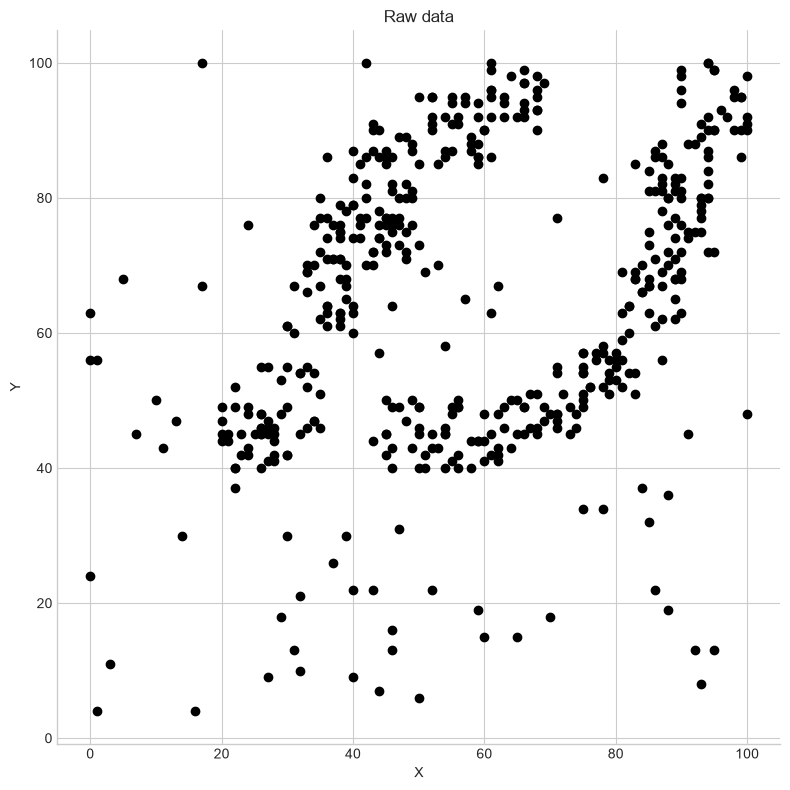

In [366]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(coordinates["X"], coordinates["Y"], c="black")
ax.set(title=f"Raw data", xlabel="X", ylabel="Y")
plt.tight_layout()
plt.show()


## The Coordinates dataset: K-means

We first repeat the $k=2\ldots6$ experiment and inspect how SSE changes.

In [367]:
coordinate_features = ["X", "Y"]
coordinate_scaler = MinMaxScaler()
X_coordinates = coordinate_scaler.fit_transform(coordinates[coordinate_features])
coordinate_models = {}
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=20, random_state=10)
    labels = model.fit_predict(X_coordinates)
    coordinate_models[k] = (model, labels)
coordinate_sse = pd.DataFrame({ "k": range(2, 7), "SSE": [coordinate_models[k][0].inertia_ for k in range(2, 7)], })
coordinate_sse["SSE reduction"] = coordinate_sse["SSE"].shift(1) - coordinate_sse["SSE"]
coordinate_sse.round(3)


,k,SSE,SSE reduction
0,2,29.177,NaN
1,3,18.709,10.468
2,4,12.060,6.649
3,5,9.539,2.520
4,6,7.738,1.802


# K-means

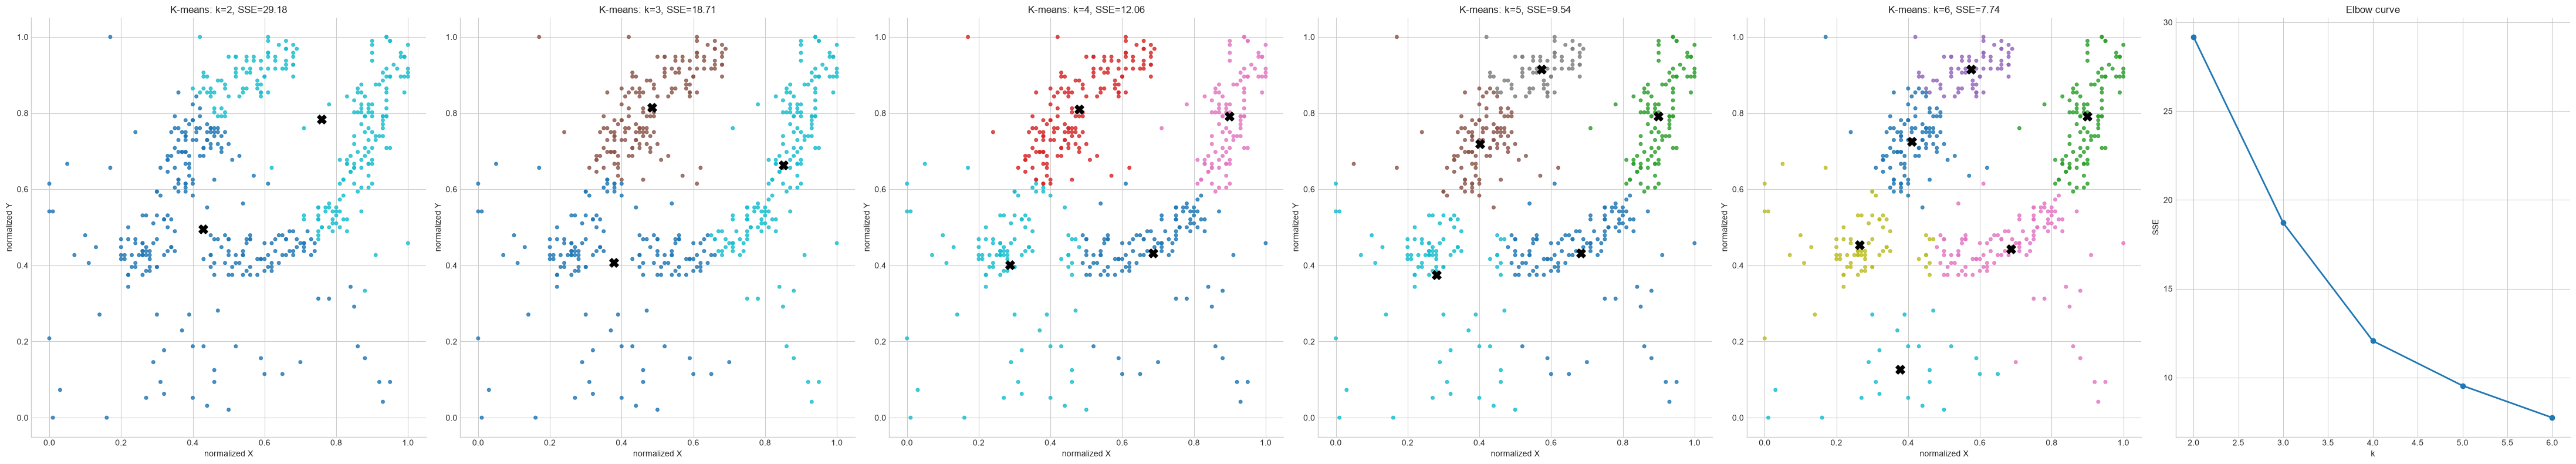

In [368]:
fig, axes = plt.subplots(1, 6, figsize=(44, 8))
for ax, k in zip(axes.flat, range(2, 7)):
    model, labels = coordinate_models[k]
    ax.scatter(X_coordinates[:, 0], X_coordinates[:, 1], c=labels, cmap="tab10", s=16, alpha=.8)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c="black", marker="X", s=120)
    ax.set(title=f"K-means: k={k}, SSE={model.inertia_:.2f}", xlabel="normalized X", ylabel="normalized Y")
axes.flat[-1].plot(coordinate_sse["k"], coordinate_sse["SSE"], marker="o", linewidth=2)
axes.flat[-1].set(title="Elbow curve", xlabel="k", ylabel="SSE")
plt.tight_layout()
plt.show()


## K-means conclusion

SSE necessarily decreases as $k$ grows, with diminishing improvements around the handout's suggested $k\approx5$.

- But the plots expose the more important limitation: K-means divides elongated natural groups into compact Voronoi regions.
- Adding centroids reduces SSE by slicing the shapes rather than discovering their full extent.
- **A density-based method is preferable**.


## The Coordinates dataset: DBSCAN

DBSCAN replaces a chosen number of clusters with two density parameters:

- `eps`: neighborhood radius, `min_samples`: minimum number of points (including the point itself) needed to define a core point.
- A k-distance plot helps identify a bend for min_samples=8.



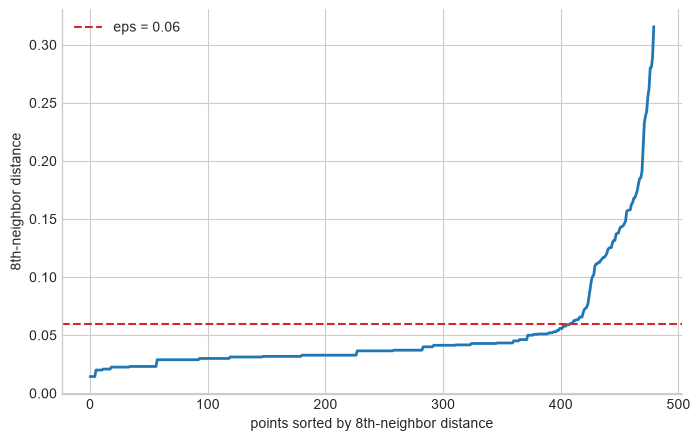

In [369]:
#| echo: false
neighbors = NearestNeighbors(n_neighbors=8).fit(X_coordinates)
distances, _ = neighbors.kneighbors(X_coordinates)
k_distances = np.sort(distances[:, -1])
plt.plot(k_distances, linewidth=2)
plt.axhline(.06, color="tab:red", linestyle="--", label="eps = 0.06")
plt.xlabel("points sorted by 8th-neighbor distance")
plt.ylabel("8th-neighbor distance")
plt.legend()
plt.show()


# DBSCAN


The handout explores `(eps, minPts)` values `(0.10,4)`, `(0.10,8)`, `(0.05,4)`, `(0.06,3)`, and `(0.06,8)` on normalized coordinates.

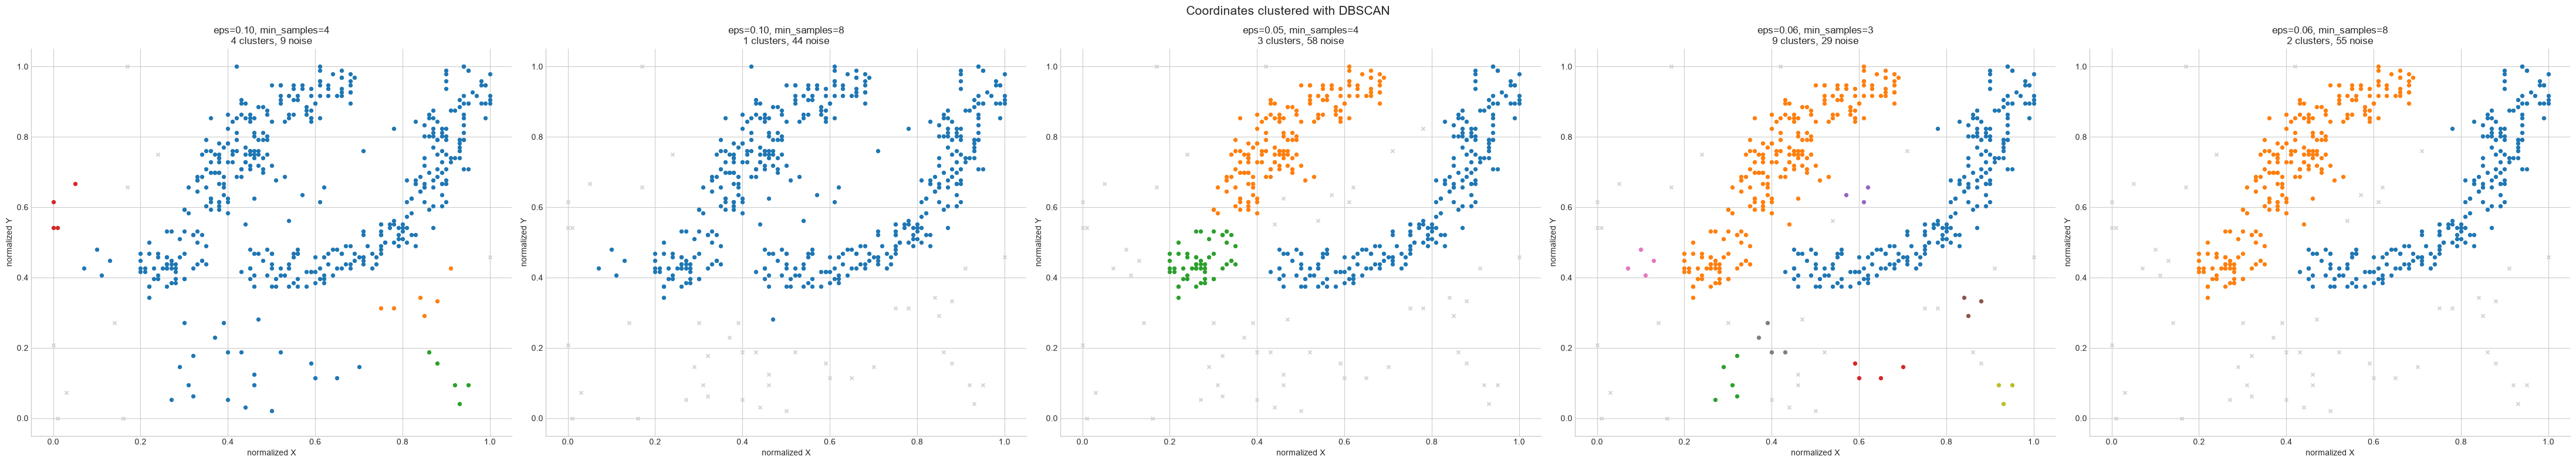

In [370]:
#| echo: false

dbscan_settings = [(.10, 4), (.10, 8), (.05, 4), (.06, 3), (.06, 8)]
dbscan_results = {}

fig, axes = plt.subplots(1, 5, figsize=(44, 8))
for ax, (eps, min_samples) in zip(axes.flat, dbscan_settings):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_coordinates)
    dbscan_results[(eps, min_samples)] = labels

    unique = sorted(set(labels))
    for label in unique:
        mask = labels == label
        if label == -1:
            ax.scatter(X_coordinates[mask, 0], X_coordinates[mask, 1], c="lightgray", s=18, marker="x", label="noise")
        else:
            ax.scatter(X_coordinates[mask, 0], X_coordinates[mask, 1], s=18, label=f"C{label}")

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    ax.set(
        title=f"eps={eps:.2f}, min_samples={min_samples}\n{n_clusters} clusters, {n_noise} noise",
        xlabel="normalized X", ylabel="normalized Y",
    )

fig.suptitle("Coordinates clustered with DBSCAN", fontsize=15)
plt.tight_layout()
plt.show()


In [371]:
#| echo: false

dbscan_summary = []
for (eps, min_samples), labels in dbscan_results.items():
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    clustered = labels != -1
    silhouette = (
        silhouette_score(X_coordinates[clustered], labels[clustered])
        if n_clusters >= 2 and clustered.sum() > n_clusters else np.nan
    )
    dbscan_summary.append({
        "eps": eps, "min_samples": min_samples,
        "clusters": n_clusters, "noise points": n_noise,
        "noise %": n_noise / len(labels), "silhouette (non-noise)": silhouette,
    })

dbscan_summary = pd.DataFrame(dbscan_summary)
dbscan_summary["eps"] = dbscan_summary["eps"].map(lambda value: f"{value:.2f}")
dbscan_summary["noise %"] = dbscan_summary["noise %"].map(lambda value: f"{value:.1%}")
dbscan_summary["silhouette (non-noise)"] = dbscan_summary["silhouette (non-noise)"].map(
    lambda value: "n/a" if pd.isna(value) else f"{value:.3f}"
)
dbscan_summary


,eps,min_samples,clusters,noise points,noise %,silhouette (non-noise)
0,0.10,4,4,9,1.9%,0.012
1,0.10,8,1,44,9.2%,n/a
2,0.05,4,3,58,12.1%,0.396
3,0.06,3,9,29,6.0%,-0.033
4,0.06,8,2,55,11.5%,0.395


## DBSCAN interpretation

<details>
<summary>Answer</summary>

The plots reproduce the handout's parameter reasoning:

- `eps=0.10, min_samples=4`: neighborhoods connect too easily, so distinct dense areas merge;
- `eps=0.10, min_samples=8`: the stronger density requirement helps with noise but the radius can still bridge natural groups;
- `eps=0.05, min_samples=4`: the small radius and low threshold can fragment dense shapes;
- `eps=0.06, min_samples=3`: the density threshold is too permissive to reject noise reliably;
- **`eps=0.06, min_samples=8`**: best balance among the tested settings, recovering elongated clusters while rejecting sparse points.

Unlike K-means, DBSCAN can trace non-spherical shapes and mark observations as noise (`label == -1`). Its parameters are scale-dependent, which is why the same normalization used by the handout is essential.
</details>


## Takeaways

1. Normalize before Euclidean-distance clustering when attributes have different ranges.
2. Read K-means beyond a single score: inspect centroids, dispersion, sizes, stability, and geometry.
3. Known labels may evaluate a clustering, but they must not enter the clustering features.
4. SSE always falls with larger $k$; look for diminishing returns and whether clusters remain meaningful.
5. K-means favors compact center-based clusters. DBSCAN is better suited to elongated shapes and explicit noise.
6. Cluster IDs are arbitrary. Interpret a cluster through its profile and members, not its number.
